# Literature Review

##### Source: Analyzing Titanic Disaster using Machine Learning Algorithms
This article analyzes the Titanic disaster using machine learning models on the Kaggle Titanic dataset. It addresses the problem of predicting passenger survival based on factors such as sex, age, passenger class, family size, and related attributes. The study preprocesses the data by handling missing values, encoding categorical variables, and creating new features like “Mother,” “Children,” “Family,” and “Respectable.” The paper compares Naïve Bayes, Logistic Regression, Decision Tree, and Random Forest models. Logistic Regression performed best with the highest accuracy and lowest false discovery rate, showing that sex and passenger class were the most important predictors of survival.

### Article Summary
The paper examines Titanic passenger records to understand survival patterns and improve classification accuracy. It includes exploratory data analysis, missing value treatment, feature engineering, and model comparison. The authors found that women and passengers in higher classes had a much higher chance of survival. Among all tested algorithms, Logistic Regression gave the best results, with accuracy around 93.5%, followed by Decision Tree and Random Forest.

### Key Survival Factors
The most important variables identified in the study were sex, passenger class, age, and family-related features. Sex was the strongest factor because females had significantly higher survival rates than males. Pclass also had a strong negative relation with survival, meaning first-class passengers were more likely to survive than third-class passengers. Age and child status also influenced survival because of the “women and children first” policy.

### Recommended Graphs for EDA
For Titanic analysis, you can use bar charts for survival by sex, histograms for age distribution, box plots for fare and age, and heatmaps for correlation between features. These graphs help show patterns before modeling and support your conclusions in the literature review and EDA section.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [3]:
df = pd.read_csv('Titanic-Dataset.csv')
df.head(15)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


# hypoyhesis

1.Gender vs Survival
- Females ka survival rate higher hoga.
2.Passenger Class vs Survival
- 1st class passengers zyada survive hue honge.
3.Family Size vs Survival
- Family size survival ko affect karta hai.
4.Age vs Survival
- Children ka survival rate better ho sakta hai.
5.Fare vs Survival
- Higher fare → higher survival chances

# KEY FINDINGS

-  Survival gender par depend karta hai
→ Females ka survival rate males se zyada tha


- Survival passenger class (Pclass) par depend karta hai
→ Higher class (Pclass 1) ke log zyada survive hue


- Survival fare (ticket price) se related hai
→ Jitna zyada fare, utna survival chance high


- Females had higher survival chances
→ “Women first” situation follow hui


- Higher-class passengers survived more
→ Better facilities aur access ki wajah se


- High-paying passengers had better survival
→ Indirectly wealth ka effect


- Family size ka bhi impact tha
→ Na bahut akela, na bahut bada family → best survival


- Embarkation point (Embarked) ka bhi thoda effect tha
→ Different locations par survival rate vary hua


# DATA ISSUE

1. Missing value
- Age
- Cabin
- Embarked
2. Categorical Columns Present
- Sex
- Embarked
- Ticket
- Cabin
- Name
# SOLUTION
- ENCODING
- Mostly drop kar dete hain.

# BASIC DATA UNDERSTANDING

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


age 0.42 se 80 tak thi, survival 0 ya 1 hai, aur dataset mein Age, Cabin, aur Embarked mein missing values hain.

In [4]:
df.shape

(891, 12)

In [5]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [7]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Age ka min 0.42 hai, matlab dataset mein ek bahut chhota baccha bhi tha.

Age ka max 80 hai, matlab sabse buzurg passenger 80 saal ka tha.

Fare ka max 512.33 hai, matlab kuch logon ne bahut expensive ticket li thi.

Pclass ka min 1 aur max 3 hai, matlab sirf 1st, 2nd aur 3rd class hi hain.

Survived ka min 0 aur max 1 hai, matlab ye binary column hai: 0 = died, 1 = survived

# Data cleaning

In [8]:
df.isnull().sum() #check missing values

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [9]:
df.dtypes #check data types

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object
dtype: object

In [10]:
df['Age'] = df['Age'].fillna(df['Age'].median()) #fill missing values in age

In [11]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0]) # fill missing values in Embarked

In [12]:
df.drop('Cabin', axis=1, inplace=True) # drop cabin column

In [13]:
df.duplicated().sum() # check duplicates values

np.int64(0)

In [14]:
 df.drop_duplicates(inplace=True) # remove  duplicates value 

# Convert Categorical Data into Numerical

###### sex encoding

In [15]:
df['Sex'] = df['Sex'].map({'male':0, 'female':1})

###### embarked encoding

In [16]:
df['Embarked'] = df['Embarked'].map({'S':0, 'C':1, 'Q':2})

###### Drop Unnecessary Columns

In [17]:
df.drop(['PassengerId','Name','Ticket'], axis=1, inplace=True)

# final cheack

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    int64  
 3   Age       891 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
 7   Embarked  891 non-null    int64  
dtypes: float64(2), int64(6)
memory usage: 55.8 KB


# UNIVERIATE ANALYSIS

# SURVIVED

In [19]:
df['Survived'].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

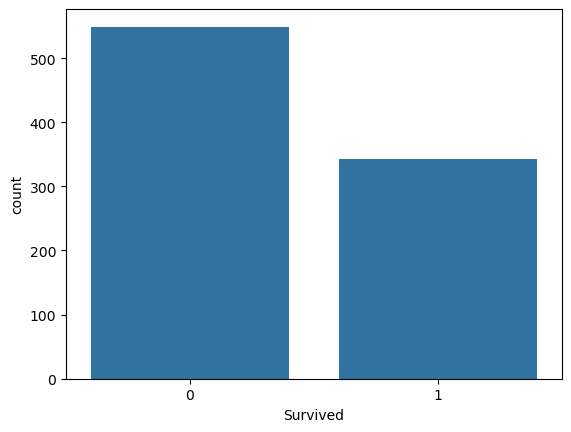

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Survived', data=df)
plt.show()

The graph shows that most passengers survive nahi kar paye. Non-survivors ki count survivors se kaafi zyada hai, jo indicate karta hai ki Titanic disaster me death rate high tha.

# Gender Distribution

In [21]:
df['Sex'].value_counts()

Sex
0    577
1    314
Name: count, dtype: int64

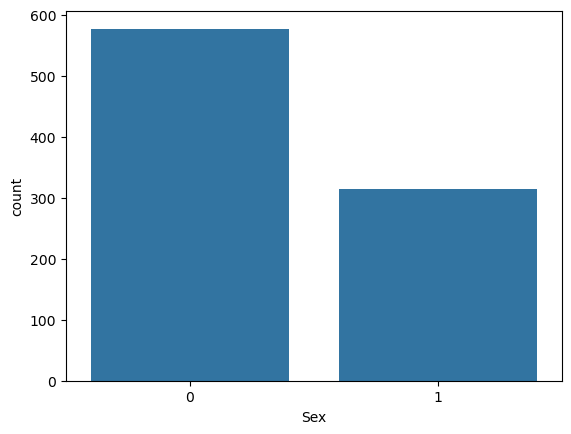

In [22]:
sns.countplot(x='Sex', data=df)
plt.show()

The graph shows that male passengers ki sankhya female passengers se kaafi zyada hai. Isse pata chalta hai ki ship me majority passengers male the.

# Passenger Class Distribution

In [23]:
df['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

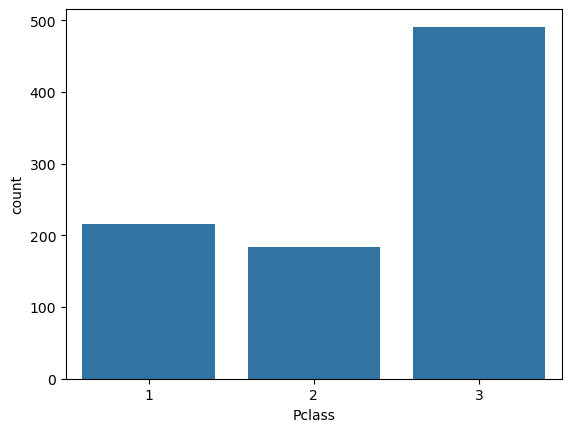

In [24]:
sns.countplot(x='Pclass', data=df)
plt.show()

The graph shows that most passengers 3rd class me travel kar rahe the, jabki 1st aur 2nd class passengers comparatively kam the. Ye indicate karta hai ki lower-class passengers ki population ship me highest thi.

# Age Distribution

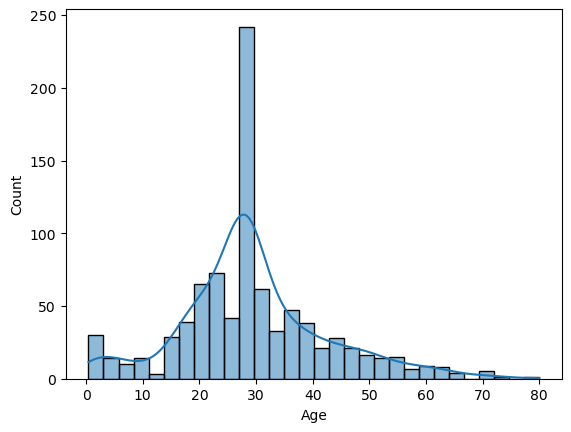

In [25]:
sns.histplot(df['Age'], kde=True)
plt.show()

The graph shows that most passengers ki age 20–35 years ke beech thi. Iska matlab dataset mainly young adult passengers ko represent karta hai, aur elderly passengers ki sankhya kaafi kam thi.

# Fare Distribution

### 

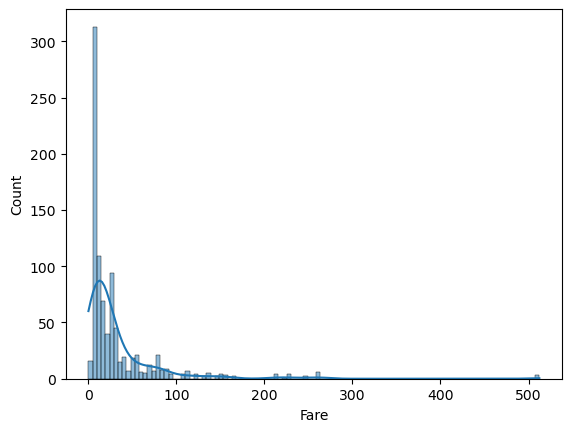

In [26]:
sns.histplot(df['Fare'], kde=True)
plt.show()

The graph shows ki most passengers ne low ticket fare pay kiya tha aur sirf kuch passengers ne bahut high fare pay kiya tha. Kuch high fare values ki wajah se graph right side ki taraf stretch ho raha hai, isliye distribution right-skewed hai. Iska matlab hai ki zyadatar passengers low fare group me the, jabki bahut kam passengers ke tickets expensive the.

# Embarked Distribution

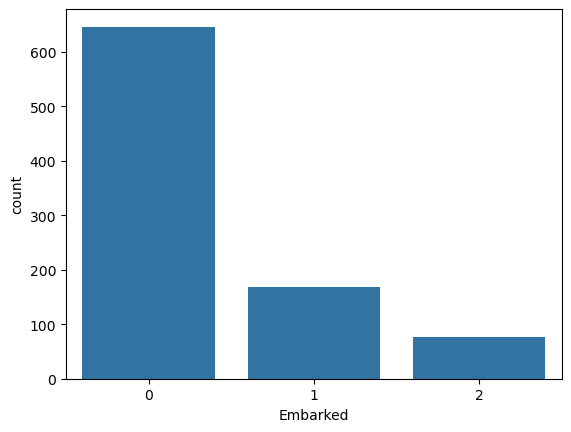

In [27]:
sns.countplot(x='Embarked', data=df)
plt.show()

The graph shows ki Titanic me sabse zyada passengers port 0 se embarked hue the. Port 1 se comparatively kam passengers aaye the aur port 2 se sabse kam passengers aaye the. Iska matlab hai ki majority passengers ne apni journey Southampton port se start ki thi, while the other two ports had fewer passengers.

# Boxplot for Outliers

# AGE

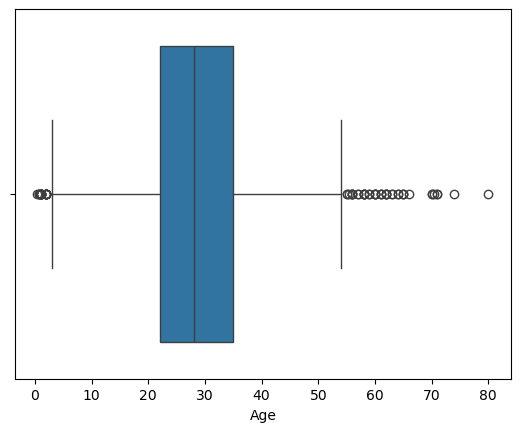

In [28]:
sns.boxplot(x=df['Age'])
plt.show()

The graph shows that Titanic ke zyadatar passengers young adults the, jahan unki median age lagbhag 28 years hai aur middle 50% passengers (box) ki umar 22 se 35 saal ke beech hai. Saath hi, graph ke dono taraf kafi saare outliers (dots) dikh rahe hain, jisme right side par elderly passengers (55 se 80 saal ke log) aur left side par bohot chhote bache (0 se 3 saal tak ke) shamil hain, jo yeh dikhata hai ki ship par har umar ke log maujood the.

# FARE

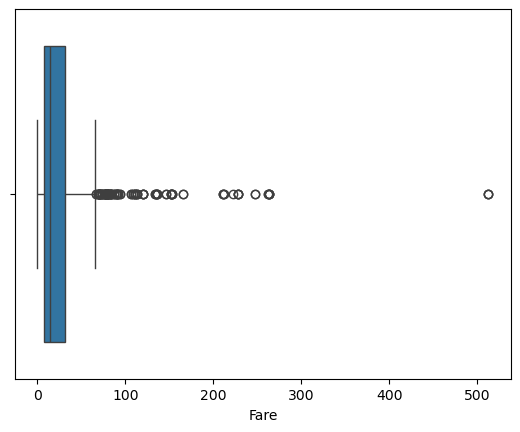

In [29]:
sns.boxplot(x=df['Fare'])
plt.show()

The graph shows that zyadatar passengers ne bohot sasta ticket kharida tha, jahan unka median fare kafi kam (around 15 se 20 ke beech) hai aur pure box ki concentration 50 se neeche hi khatam ho jati hai. Saath hi, graph me right side par kafi lambi line aur bohot saare extreme outliers (dots) dikh rahe hain jo 100 se lekar 500+ tak ja rahe hain, jisse pata chalta hai ki dataset me fare kafi skewed hai aur kuch bohot hi ameer passengers the jinhone extraordinarily mehnga ticket kharida tha.

In [30]:
# Biveriate analysis

### Sex vs Survival

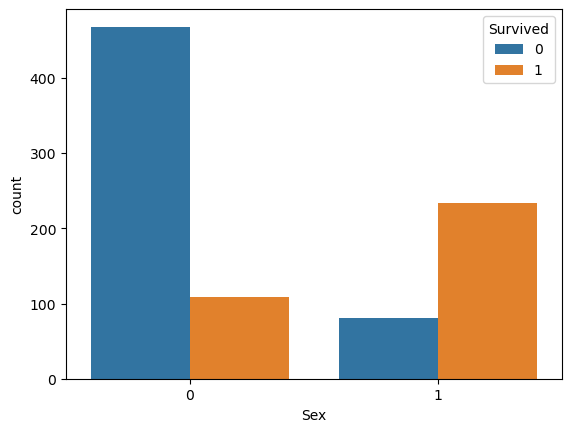

In [31]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

The graph shows ki male passengers (0) ki total count female passengers (1) se kaafi zyada thi. Male category me non-survivors ki count bahut high hai, jo indicate karta hai ki zyadatar male passengers survive nahi kar paye.

Dusri taraf, female passengers me survivors ki count non-survivors se zyada hai, which means females ke survival chances males compared better the. Ye graph clearly show karta hai ki gender ka survival par strong impact tha, aur women were given higher priority during rescue operations.

# Pclass vs Survival

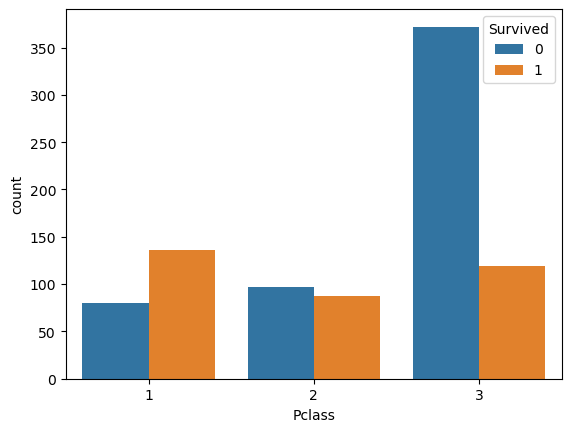

In [32]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

The graph shows ki passengers mostly 3rd class me travel kar rahe the. 3rd class passengers me non-survivors ki count bahut zyada hai, which means zyadatar lower-class passengers survive nahi kar paye.

1st class passengers me survivors ki count non-survivors se zyada hai, jo indicate karta hai ki higher-class passengers ke survival chances better the. 2nd class me survivors aur non-survivors almost similar hain.

Ye isliye hua hoga kyuki 1st class passengers rich aur upper deck ke paas the, jisse unhe lifeboats aur rescue facilities tak jaldi access mil gaya. On the other hand, 3rd class passengers lower section me the aur unhe rescue tak pahuchne me zyada difficulty hui.

# Age vs Survival

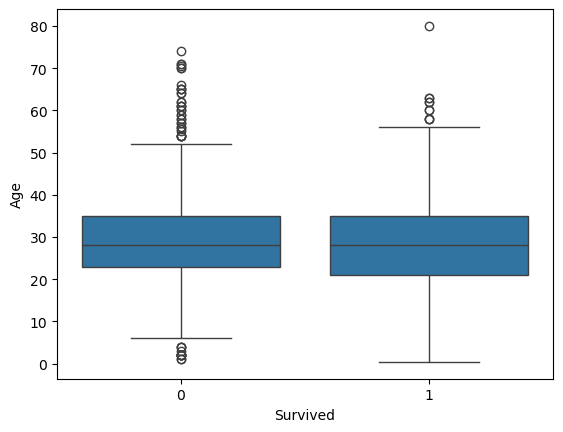

In [33]:
sns.boxplot(x='Survived', y='Age', data=df)
plt.show()

The graph shows that dono groups (survived aur non-survived) ka median age lagbhag same (around 28 years) hai, jisse pata chalta hai ki overall age ka survival par koi bohot bada direct asar nahi tha. Halanki, non-survived group (0) me kafi saare elderly outliers (55 se 75+ umar ke log) dikh rahe hain jo survive nahi kar paye, jabki survived group (1) ke lower section se pata chalta hai ki chhote bachon (low age) ke bachne ki sambhavna thodi behtar thi.

# Fare vs Survival

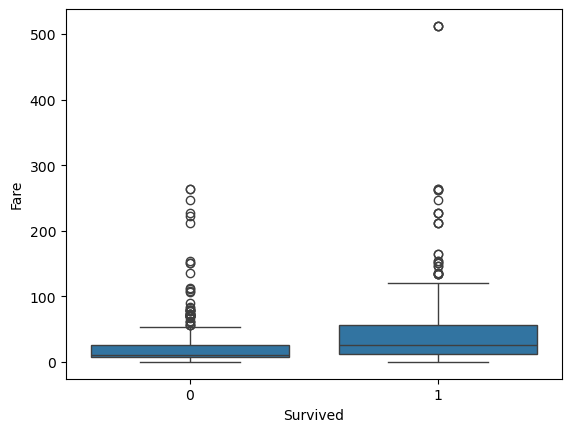

In [34]:
sns.boxplot(x='Survived', y='Fare', data=df)
plt.show()

The graph shows that survive karne wale passengers (1) ka median ticket fare nahi survive karne walo (0) se zyada hai, aur non-survivors ka fare sabse kam range me concentrated hai, jisse saaf pata chalta hai ki kam fare dene wale lower-class passengers ke bachne ke chances bohot kam the. Saath hi, zyadatar high-fare outliers (100 se 500+ wale mehnge tickets) survived group me hain, jiska matlab hai ki mehnga ticket lene wale high-class passengers ke survival chances kafi better the.

# Embarked vs Survival

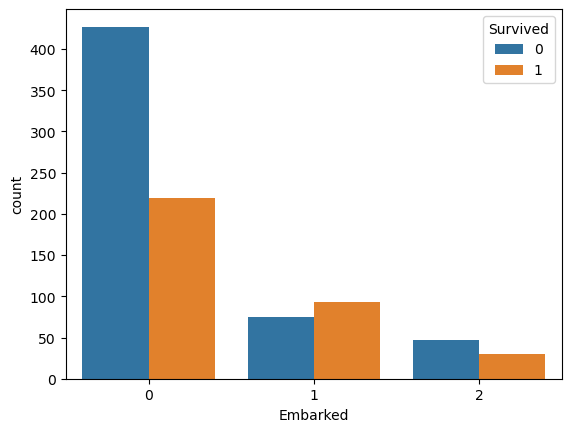

In [35]:
sns.countplot(x='Embarked', hue='Survived', data=df)
plt.show()

The graph shows that port '0' se board karne wale passengers ki sankhya (count) sabse zyada thi, lekin unme se adhe se zyada log survive nahi kar paye (0). Wahin port '1' se board karne wale passengers ka survival rate better tha kyunki wahan survive karne walo (1) ka count nahi survive karne walo se zyada hai, jabki port '2' par dono ka count kaafi kam aur lagbhag barabar hai.

# Multivariate Analysis

# Pclass, Sex and Survival

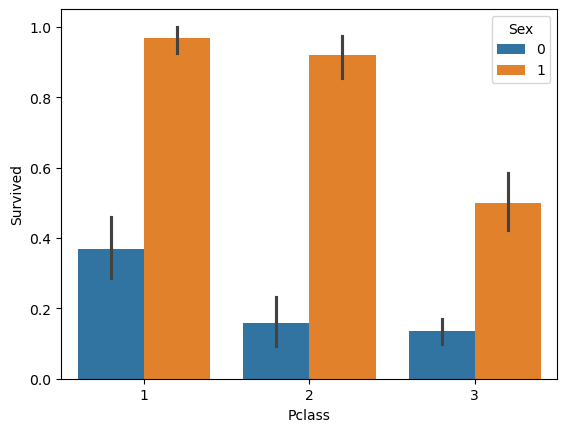

In [36]:
sns.barplot(x='Pclass', y='Survived', hue='Sex', data=df)
plt.show()

The graph shows that har ek passenger class (1, 2, aur 3) me group '1' (Females) ka survival rate group '0' (Males) se kafi zyada hai, jo yeh confirm karta hai ki rescue ke waqt females ko priority mili thi. Saath hi, class 1 aur class 2 ke group '1' (females) ka survival rate lagbhag 90% se upar hai, jabki class 3 me aate-aate dono hi genders ka survival rate kafi kam ho jata hai, jisse pata chalta hai ki upper class passengers ke bachne ke chances sabse behtar the.

# Age, Fare and Survival

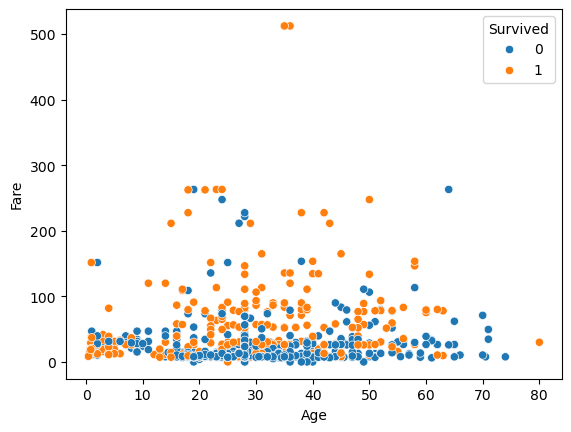

In [37]:
sns.scatterplot(x='Age', y='Fare', hue='Survived', data=df)
plt.show()

The graph shows that zyadatar passengers low fare range (0 se 50 ke beech) me hain jahan blue dots (non-survived) ki sankhya bohot zyada hai, jabki jaise-jaise ticket ka fare (price) badhta hai, orange dots (survived) dominate karne lagte hain. Saath hi, graph me dikh raha hai ki 0 se 10 saal ke chhote bachon (low age) ke liye orange dots kafi zyada hain, jisse pata chalta hai ki kam age ke bachon aur mehnga ticket lene wale passengers ke survive karne ke chances sabse zyada the.

# Heatmap

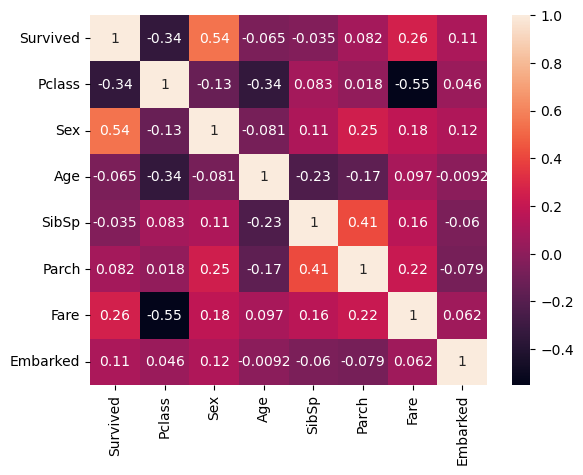

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(df.corr(numeric_only=True), annot=True)
plt.show()

The graph shows that survival rate ka sabse strong positive correlation 'Sex' (0.54) ke saath hai, jo yeh confirm karta hai ki females ke survive karne ke chances sabse zyada the. Saath hi, 'Survived' aur 'Pclass' ke beech negative correlation (-0.34) hai, jiska matlab hai ki jaise-jaise class number badhta hai (yaani 1st class se 3rd class ki taraf), survival ke chances kam ho jate hain, jabki 'Fare' aur 'Survived' ke beech positive correlation (0.26) dikhata hai ki mehnga ticket lene walo ka survival rate behtar tha.

# HIDDEN GRAPH

# Embarked vs Fare

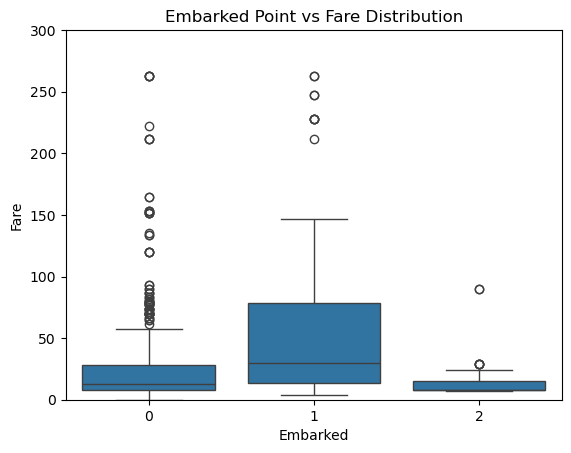

In [39]:
import seaborn as sns
import matplotlib.pyplot as plt

# Graph 1: Embarked vs Fare 
sns.boxplot(x='Embarked', y='Fare', data=df)
plt.title('Embarked Point vs Fare Distribution')
plt.ylim(0, 300) # Extreme outliers ko hide karne ke liye taaki box plot saaf dikhe
plt.show()

The graph shows that port '1' (Cherbourg) ka median ticket price baaki dono ports se kafi zyada high hai. Iska hidden insight yeh hai ki Cherbourg boarding point ka survival par direct asar nahi tha, balki wahan se zyadatar ameer yaani Class 1 ke passengers ne board kiya tha, jinhone bohot mehnga ticket kharida tha. Is vajah se unke bachne ke chances automatically high ho gaye

# Pclass vs Survived

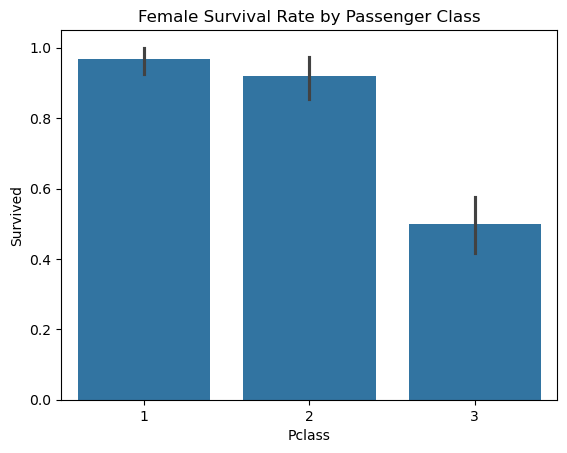

In [40]:
# Graph 2: Sirf Female passengers (Sex == 1) ka data filter karke Class Divide check karna
females_df = df[df['Sex'] == 1]
s
sns.barplot(x='Pclass', y='Survived', data=females_df)
plt.title('Female Survival Rate by Passenger Class')
plt.show()

The graph shows that halanki females ka overall survival rate kafi accha tha, lekin unke beech bhi ek bada class divide tha. Class 1 aur Class 2 ki females ka survival rate lagbhag 90% se upar (strongly close to 1.0) hai, jabki Class 3 ki females ka survival rate seedha girkar lagbhag 50% (0.5) par aa jata hai. Isse pata chalta hai ki female hone ke baad bhi agar koi 3rd class me tha, toh unhe rescue me utni priority nahi mili jitni 1  class ki females ko mili.

# Family Size vs Survived

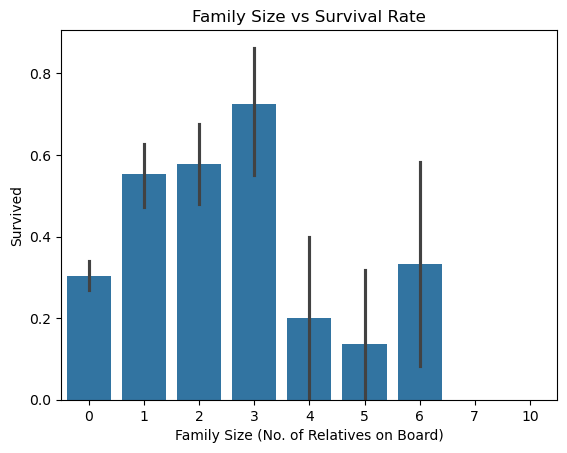

In [41]:
# Graph 3: Family Size nikalna aur uska Survival par asar dekhna
df['FamilySize'] = df['SibSp'] + df['Parch']

sns.barplot(x='FamilySize', y='Survived', data=df)
plt.title('Family Size vs Survival Rate')
plt.xlabel('Family Size (No. of Relatives on Board)')
plt.show()

The graph shows that akele travel karne wale passengers (Family Size 0) ka survival rate kafi kam (lagbhag 30%) tha.

Wahin, jin passengers ki family size 1 se 3 members ki thi, unka survival rate sabse best (up to 70%+) chal raha hai.

Lekin jaise hi family size 4 ya usse zyada hoti hai, survival rate achanak se bohot niche gir jata hai. Iska hidden pattern yeh hai ki akele log bina kisi support ke reh gaye aur bohot bade parivar ek-dusre ko dhundhne aur bachane ke chakkar me pichhe chhut gaye, jabki mofussil yaani small families (1-3 members) jaldi se ek sath lifeboats tak pahonchne me kamyab rahin.



---

### **📌 Titanic EDA Project: Final Summary Report**

#### **1. Project Objective **

Is project ka main objective Titanic dataset ka gahraai se analysis karna tha taaki yeh pata lagaya ja sake ki kaunse factors (features) ne passengers ke bachne (Survival) par sabse zyada asar dala. Isme humne alag-alag hypotheses ko test kiya jaise Gender, Social Class (Pclass), Age, Fare, aur Family Size.

---

#### **2. Data Cleaning & Preprocessing (Data Preparation)**

Model building ya final conclusion par pahonchne se pehle data ko achhe se clean kiya gaya:

* **Missing Values:** `Age` ki missing values ko uske *median* se aur `Embarked` ki missing values ko *mode* se fill kiya gaya. `Cabin` column me bohot zyada data missing tha, isliye use drop kar diya gaya.
* **Feature Encoding:** Categorical data ko machine-readable format me convert kiya gaya (`Sex` -> Male: 0, Female: 1; `Embarked` -> S: 0, C: 1, Q: 2).
* **Feature Selection:** Unnecessary columns jaise `PassengerId`, `Name`, aur `Ticket` ko drop kiya gaya kyunki inka survival se koi direct rishta nahi tha.

---

#### **3. Key General Findings **

* **Gender Dominance:** Titanic par travel karne walo me males ki sankhya kafi zyada thi, lekin bachne walo me Females ka ratio sabse high tha. Correlation heatmap me bhi `Sex` aur `Survived` ke beech sabse strong positive correlation (**0.54**) mila.
* **Class & Wealth Divide:** Zyadatar passengers 3rd class (low fare) me the, aur isi class me marne walo ki sankhya sabse zyada thi. Wahin, 1st class ke mehnge ticket wale passengers ke bachne ke chances bohot high the.
* **Age Distribution:** Ship par zyadatar young adults (20-35 saal) the. Data se pata chala ki elderly logo (55+ saal) ke mukable chhote bachon ke bachne ka rate behtar tha.

---

#### **4. Deep Hidden Pattern **

Normal analysis ke alawa, jab humne data ko thoda aur deeply investigate kiya, toh **3 bade hidden patterns** samne aaye:

* **The Cherbourg Connection (Embarked vs Fare):** * *Insight:* Box plot se pata chala ki Port '1' (Cherbourg) se board karne wale passengers ka ticket fare baaki ports se kafi high tha. Iska hidden pattern yeh hai ki Cherbourg se zyadatar ameer log board hue the, isliye is port ka survival rate baki ports se behtar dikh raha tha.
* **The Female Class Divide (Pclass vs Survived for Females):**
* *Insight:* "Women and children first" ka rule toh chala, par usme bhi bhedbhav tha. Class 1 aur Class 2 ki females ka survival rate **90% se upar** tha, jabki Class 3 (poor class) ki females ka survival rate drop hokar seedha **50%** par aa gaya. Yaani female hone ke baad bhi gareeb class ki khwateen ke bachne ke chances sirf 50-50 the.


* **The Family Size Rule (Family Size vs Survival Rate):**
* *Insight:* Jo log bilkul akele the (Family Size: 0), unka survival rate kafi kam (around 30%) tha. Sabse best survival unka tha jinki family me **1 se 3 members** the (small families). Jaise hi family size 4 ya usse badi hui, survival rate achanak gir gaya, kyunki bade parivar disaster ke waqt ek-dusre ko dhundhne me hi pichhe chhut gaye.



---

### **🏁 Final Conclusion **

Titanic disaster sirf ek kismat ka khel nahi tha, balki yeh **Socio-Economic Status (Amiri-Garibi)** aur **Gender Priority** ka ek jeeta-jaata udaharan tha. Agar aap ek **Female** the aur aapne **High Fare (1st/2nd Class)** diya tha, aur aap ek **Chhoti Family** ke sath the, toh aapke bachne ke chances sabse zyada (almost 95%+) the. Wahin ek akela male passenger jo 3rd class me tha, uske bachne ke chances sabse kam the.